In [2]:
import pickle
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from IPython.display import display, HTML
from scipy.optimize import fmin
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))
np.set_printoptions(edgeitems=30, linewidth=100000)
np.set_printoptions(formatter={'complex_kind': '{:.6f}'.format})

In [3]:
def Id(dim):
    return np.diag(np.ones(dim))

def vecId(dim):
    return Id(dim).flatten()

def dim_from_vectorized_op(vec_op):
    dim = np.sqrt(len(vec_op))
    if not dim.is_integer():
        raise ValueError("The vector is not a vectorization of a square matrix.")
    dim = int(dim)
    return dim

def dim_of_square_mat(mat):
    if not (np.shape(mat)[0]==np.shape(mat)[1]):
        raise ValueError('Input is not a square matrix.')
    return np.shape(mat)[0]

def den_mat_from_vectorized_op(vec_op):
    dim=dim_from_vectorized_op(vec_op)
    return vec_op.reshape((dim, dim),order='F')

def trace_of_vectorized_op(vec_op):
    dim=dim_from_vectorized_op(vec_op)
    return np.inner(vecId(dim),vec_op)

def calc_anti_hermitian(J):
    dim = dim_of_square_mat(J)
    J_dagger_J = np.matmul(np.transpose(np.conjugate(J)), J)
    return -1/2*(np.kron(Id(dim), J_dagger_J) + np.kron(np.transpose(J_dagger_J),Id(dim)))
    
def calc_jump_channel(J):
    return np.kron(np.conjugate(J),J)

def calc_hermitian(H):
    dim = dim_of_square_mat(H)
    return - 1j*(np.kron(Id(dim),H) - np.kron(np.transpose(H), Id(dim)))

def calc_Liouville(H, Jump_op_list):
    dim_H = dim_of_square_mat(H)
    Liouville = calc_hermitian(H)
    for J in Jump_op_list:
        dim_J = dim_of_square_mat(J)
        if not dim_H==dim_J:
            raise ValueError('The jump operators and the Hamiltonian do not have the same size.')
        
        Liouville = Liouville + calc_jump_channel(J)
        Liouville = Liouville + calc_anti_hermitian(J)
    return Liouville

In [4]:
def calc_steady_state(Liouville):
    rho_steady = sc.linalg.null_space(Liouville)

    shape_rho_steady = np.shape(rho_steady)
    num_steady_states = shape_rho_steady[1]
    
    if not num_steady_states==1:
        raise ValueError('We have '+str(num_steady_states)+' steady states.')
    
    rho_steady=rho_steady.flatten()
    rho_steady = rho_steady/trace_of_vectorized_op(rho_steady)
    
    return rho_steady

def calc_Drazin_inv(Liouville, vec_steady_state):
    dim=dim_from_vectorized_op(vec_steady_state)

    Drazin_inv = np.linalg.pinv(Liouville)
    projector = Id(dim**2) - np.outer(vec_steady_state,vecId(dim))
    Drazin_inv = np.matmul(projector,np.matmul(Drazin_inv,projector))
    return Drazin_inv


def calc_F_D_SNR(Liouville_Drazin_inv, current_op_list, ws, vec_steady_state):
    dim = dim_from_vectorized_op(vec_steady_state)

    if not len(ws) == len(current_op_list):
        raise ValueError('The number of jump channels and number of current coefficients do not match')
    
    sum_of_weighted_current_op = np.zeros((dim**2, dim**2))
    F = 0
    D = 0

    for idx in range(len(current_op_list)):
        sum_of_weighted_current_op = sum_of_weighted_current_op + ws[idx]*current_op_list[idx]
        
        F = F + ws[idx] * trace_of_vectorized_op(current_op_list[idx].dot(vec_steady_state))        
        D = D + (ws[idx]**2) * trace_of_vectorized_op(current_op_list[idx].dot(vec_steady_state))
        
    
    correction = 2 * trace_of_vectorized_op(np.matmul(sum_of_weighted_current_op, np.matmul(Liouville_Drazin_inv, sum_of_weighted_current_op)).dot(vec_steady_state))
    D = D - correction
    
    return F, D, (F**2)/D

In [5]:
def evaluate_SNR(Liouville, current_op_list, ws, output_rho_steady_mat=False, output_Drazin=False):
    
    vec_steady_state = calc_steady_state(Liouville)
    dim = dim_from_vectorized_op(vec_steady_state)

    Liouville_Drazin_inv = calc_Drazin_inv(Liouville, vec_steady_state)
    F, D, SNR = calc_F_D_SNR(Liouville_Drazin_inv, current_op_list, ws, vec_steady_state)

    #sanity/validity checks:
    check_steady_state = np.allclose(Liouville.dot(vec_steady_state),np.zeros(dim**2))
    check1 = np.allclose(np.matmul(Liouville, np.matmul(Liouville_Drazin_inv, Liouville)), Liouville)
    check2 = np.allclose(np.matmul(Liouville_Drazin_inv, np.matmul(Liouville, Liouville_Drazin_inv)), Liouville_Drazin_inv)
    check3 = np.allclose(np.matmul(Liouville, Liouville_Drazin_inv), np.matmul(Liouville_Drazin_inv, Liouville))
    
    check_F_real = np.allclose(np.imag(F),0)
    check_D_real = np.allclose(np.imag(D),0)
    check_SNR_real = np.allclose(np.imag(SNR),0)
    
    if not check_F_real:
        raise ValueError('F constains a non-zero imaginary part.')
    if not check_D_real:
        raise ValueError('D constains a non-zero imaginary part.')
    if not check_SNR_real:
        raise ValueError('The SNR constains a non-zero imaginary part.')
    if not check_steady_state:
        raise ValueError('The steady state does not satisfy the property of a steady state.')
    if not check1:
        raise ValueError('The Drazin inverse does not satisfy property 1 of the group inverse.')
    if not check2:
        raise ValueError('The Drazin inverse does not satisfy property 2 of the group inverse!')
    if not check3:
        raise ValueError('The Drazin inverse does not satisfy property 3 of the group inverse!')
    
    F = np.real(F)
    D = np.real(D)
    SNR = np.real(SNR)

    if output_rho_steady_mat:
        if output_Drazin:
            return F, D, SNR, den_mat_from_vectorized_op(vec_steady_state), Liouville_Drazin_inv
        else:
            return F, D, SNR, den_mat_from_vectorized_op(vec_steady_state)
    else:
        if output_Drazin:
            return F, D, SNR, Liouville_Drazin_inv
        else:
            return F, D, SNR

# Single Qubit Clockwork

In [6]:
H = np.diag([-1/2, 1/2])

def ket_phi(phi):
    return 1/np.sqrt(2)*np.array([[1],[np.exp(1j*np.pi*phi)]])

def J_phi(phi):
    return np.matmul(ket_phi(phi),np.transpose(ket_phi(0)))

def qubit_clock_SNR(x):
    # x[0]: energy
    # x[1]: angle phi

    J=J_phi(x[1])
    current_op = calc_jump_channel(J)

    Liouville = calc_Liouville(H*x[0],[J])

    _,_, SNR = evaluate_SNR(Liouville,[current_op],[1])
    return SNR

def neg_qubit_clock_SNR(x):
    return -qubit_clock_SNR(x)

Optimization terminated successfully.
         Current function value: -1.187344
         Iterations: 26
         Function evaluations: 53
The maximum SNR (1.18734) is reached at an energy of 0.835924 and an angle of  1.15124 \pi


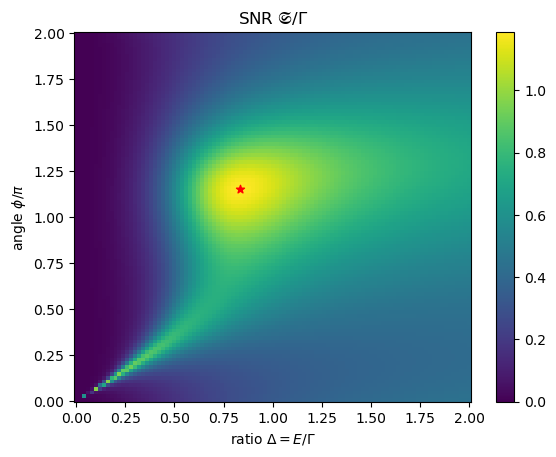

In [7]:
opt_pars_qubit_clockwork = {}

energies = np.linspace(0,2,101)
angles = np.linspace(0.005,2-0.005,101)
SNRs = np.zeros((len(angles), len(energies)))

for idx_1, energy in enumerate(energies):
    for idx_2, angle in enumerate(angles):
        SNRs[idx_2,idx_1] = qubit_clock_SNR([energy,angle])
        
# let us optimize the single qubit clock:
min_pars = fmin(neg_qubit_clock_SNR,[1,1])
min_value = neg_qubit_clock_SNR(min_pars)

opt_pars_qubit_clockwork['E'] = min_pars[0]
opt_pars_qubit_clockwork['phi'] = min_pars[1]

with open('opt_pars_qubit_clockwork.pickle', 'wb') as handle:
    pickle.dump(opt_pars_qubit_clockwork, handle, protocol=pickle.HIGHEST_PROTOCOL)

#colorpalette
my_cmap = sns.color_palette('viridis', as_cmap=True)

fig, ax = plt.subplots()
im = ax.pcolormesh(energies, angles, SNRs,norm='linear',cmap=my_cmap)
#plt.hlines(1,-1,1, color='black', linestyles='dashed')
ax.set_xlabel(r'ratio $\Delta = E/\Gamma$')
ax.set_ylabel(r'angle $\phi/\pi$')
#ax.set_yticks([0,0.25,0.5,0.75,1,1.25,1.5,1.75,2],labels=[0,0.25,0.5,0.75,1,1.25,1.5,1.75,2])
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars[0],min_pars[1], color='red', marker='*')
fig.colorbar(im, ax=ax)

print(r'The maximum SNR (%g) is reached at an energy of %g and an angle of  %g \pi'%(-min_value,min_pars[0],min_pars[1]))

# Two Qubit Clockworks with Feedback

In [8]:
Projm1 = np.diag([1,0])
Projm2 = np.diag([0,1])
Ketbra12 = np.array([[0,1],[0,0]])
Ketbra21 = np.array([[0,0],[1,0]])

def H1m1(E1):
    return np.kron(H*E1,np.kron(Id(2),Projm1))
def H1m2(E2):
    return np.kron(H*E2,np.kron(Id(2),Projm2))
def H2m1(E2):
    return np.kron(Id(2),np.kron(H*E2,Projm1))
def H2m2(E1):
    return np.kron(Id(2),np.kron(H*E1,Projm2))

def J1m1(phi):
    return np.kron(J_phi(phi), np.kron(Id(2), Projm1))
def J1m2(phi):
    return np.kron(J_phi(phi), np.kron(Id(2), Ketbra12))
def J2m1(phi):
    return np.kron(Id(2), np.kron(J_phi(phi), Ketbra21))
def J2m2(phi):
    return np.kron(Id(2), np.kron(J_phi(phi), Projm2))

def construct_Lioville_and_current_op_list_under_2qubitfeedback(E1,E2,phi):
    H = H1m1(E1) + H1m2(E2) + H2m1(E2) + H2m2(E1)
    Lioville = calc_Liouville(H, [J1m1(phi),J1m2(phi),J2m1(phi),J2m2(phi)])
    current_op_list = [calc_jump_channel(J1m1(phi)),calc_jump_channel(J1m2(phi)),calc_jump_channel(J2m1(phi)),calc_jump_channel(J2m2(phi))]

    return Lioville, current_op_list

def SNR_under_2qubitfeedback(x):
    # x[0]: alpha_1
    # x[1]: alpha_2
    Liouville, Jump_op_list = construct_Lioville_and_current_op_list_under_2qubitfeedback(x[0]*min_pars[0],x[1]*min_pars[0],min_pars[1])
    _,_, SNR = evaluate_SNR(Liouville,Jump_op_list,[1,1,1,1])
    return SNR

def neg_SNR_under_2qubitfeedback(x):
    return -SNR_under_2qubitfeedback(x)

In [9]:
opt_pars_Pi_switch = {}

min_pars_2qubitfeedback = fmin(neg_SNR_under_2qubitfeedback,[0.93,1.02])
max_value_2qubitfeedback = SNR_under_2qubitfeedback(min_pars_2qubitfeedback)
print(r'The maximum SNR (%g) is reached at $\alpha_1=$ %g and $\alpha_2=$ %g'%(max_value_2qubitfeedback,min_pars_2qubitfeedback[0],min_pars_2qubitfeedback[1]))

opt_pars_Pi_switch['alpha_1'] = min_pars_2qubitfeedback[0]
opt_pars_Pi_switch['alpha_2'] = min_pars_2qubitfeedback[1]

with open('opt_pars_Pi_switch.pickle', 'wb') as handle:
    pickle.dump(opt_pars_Pi_switch, handle, protocol=pickle.HIGHEST_PROTOCOL)

Optimization terminated successfully.
         Current function value: -2.593489
         Iterations: 30
         Function evaluations: 59
The maximum SNR (2.59349) is reached at $\alpha_1=$ 1.19621 and $\alpha_2=$ 0.881738


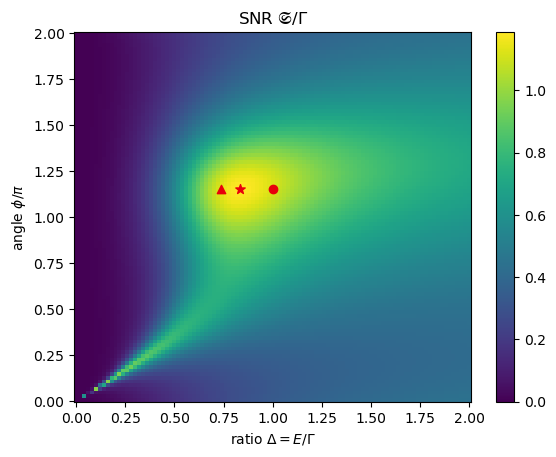

In [10]:
color_list = sns.color_palette("bright")

fig, ax = plt.subplots()
im = ax.pcolormesh(energies, angles, SNRs,norm='linear',cmap=my_cmap)
ax.set_xlabel(r'ratio $\Delta = E/\Gamma$')
ax.set_ylabel(r'angle $\phi/\pi$')
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars[0],min_pars[1], color=color_list[3], marker='*', s=50)
ax.scatter(min_pars[0]*(min_pars_2qubitfeedback[0]),min_pars[1], color=color_list[3], marker='o')
ax.scatter(min_pars[0]*(min_pars_2qubitfeedback[1]),min_pars[1], color=color_list[3], marker='^')
fig.colorbar(im, ax=ax)

plt.savefig('qubit_clockwork_Python_SNR.png',dpi=600)

In [11]:
Alpha1s = np.linspace(0.25,2.25,101)
Alpha2s = np.linspace(0.25,1.75,101)
SNRs_feedback_landscape = np.zeros((len(Alpha2s), len(Alpha1s)))

for idx_1, alpha1 in enumerate(Alpha1s):
    for idx_2, alpha2 in enumerate(Alpha2s):
        SNRs_feedback_landscape[idx_2,idx_1] = SNR_under_2qubitfeedback([alpha1,alpha2])

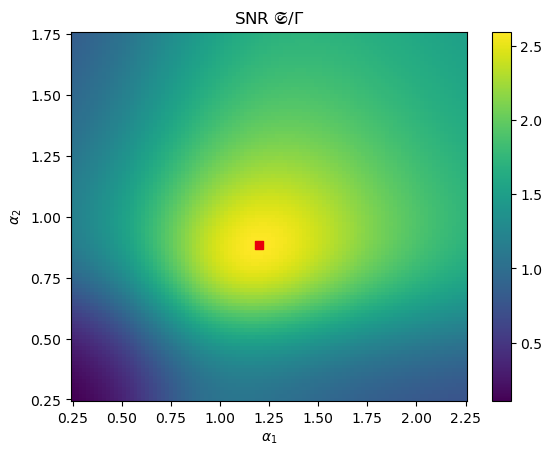

In [12]:
fig, ax = plt.subplots()
im = ax.pcolormesh(Alpha1s, Alpha2s, SNRs_feedback_landscape, norm='linear',cmap=my_cmap)
ax.set_xlabel(r'$\alpha_1$')
ax.set_ylabel(r'$\alpha_2$')
ax.set_yticks([0.25,0.5,0.75,1,1.25,1.5,1.75])
ax.set_title(r'SNR $\mathfrak{S}/\Gamma$')
ax.scatter(min_pars_2qubitfeedback[0],min_pars_2qubitfeedback[1], color=color_list[3], marker='s')
fig.colorbar(im, ax=ax)

plt.savefig('qubit_clockwork_feedback_landscape_Python_SNR.png',dpi=600)

# Robustness against dephasing

### Single qubit Clockwork with dephasing

In [13]:
def dephasing(gamma):
    return np.sqrt(gamma)*np.diag([1,-1])

def qubit_clock_SNR_with_dephasing(x, gamma):
    H = np.diag([-1/2, 1/2])
    J=J_phi(x[1])
    
    current_op_list = [calc_jump_channel(J), calc_jump_channel(dephasing(gamma))]
    Liouville = calc_Liouville(H*x[0],[J,dephasing(gamma)])

    _,_, SNR = evaluate_SNR(Liouville,current_op_list,[1,0])
    return SNR

### Two qubit clockworks with feedback and dephasing

In [14]:
def dephasing1(gamma):
    return np.kron(dephasing(gamma),np.kron(Id(2),Id(2)))
def dephasing2(gamma):
    return np.kron(Id(2),np.kron(dephasing(gamma),Id(2)))

def construct_Lioville_and_current_op_list_under_2qubitfeedback_with_dephasing(E1,E2,phi,gamma):
    H = H1m1(E1) + H1m2(E2) + H2m1(E2) + H2m2(E1)
    Lioville = calc_Liouville(H, [J1m1(phi),J1m2(phi),J2m1(phi),J2m2(phi),dephasing1(gamma),dephasing2(gamma)])
    current_op_list = [calc_jump_channel(J1m1(phi)),calc_jump_channel(J1m2(phi)),calc_jump_channel(J2m1(phi)),calc_jump_channel(J2m2(phi)),
                       calc_jump_channel(dephasing1(gamma)),calc_jump_channel(dephasing2(gamma))]

    return Lioville, current_op_list

def SNR_under_2qubitfeedback_with_dephasing(x,gamma):
    # x[0]: alpha_1
    # x[1]: alpha_2
    Liouville, Jump_op_list = construct_Lioville_and_current_op_list_under_2qubitfeedback_with_dephasing(x[0]*min_pars[0],x[1]*min_pars[0],min_pars[1],gamma)
    _,_, SNR = evaluate_SNR(Liouville,Jump_op_list,[1,1,1,1,0,0])
    return SNR

In [15]:
Gammas=np.linspace(-3,np.log10(5),501)
Gammas=10**Gammas
SNRs_no_feedback_under_dephasing = np.zeros((len(Gammas)))
SNRs_with_feedback_under_dephasing = np.zeros((len(Gammas)))

for idx, gamma in enumerate(Gammas):
    SNRs_no_feedback_under_dephasing[idx] = 2*qubit_clock_SNR_with_dephasing(min_pars,gamma)
    SNRs_with_feedback_under_dephasing[idx] = SNR_under_2qubitfeedback_with_dephasing([opt_pars_Pi_switch['alpha_1'], opt_pars_Pi_switch['alpha_2']],gamma)

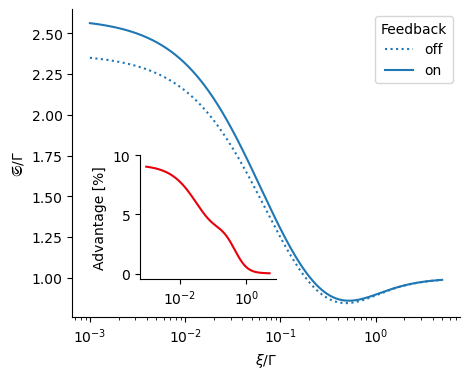

In [16]:
fig, (ax1) = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(5)
ax1.semilogx(Gammas, SNRs_no_feedback_under_dephasing,linestyle='dotted',label='off',color='tab:blue')
ax1.semilogx(Gammas, SNRs_with_feedback_under_dephasing,linestyle='solid', label='on',color='tab:blue')
ax1.set_xlabel(r'$\xi/\Gamma$')
ax1.set_ylabel(r'$\mathfrak{S}/\Gamma$')
ax1.legend(title='Feedback')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

inset_ax = ax1.inset_axes([0.175,0.125,0.35,0.4])
inset_ax.semilogx(Gammas, 100*SNRs_with_feedback_under_dephasing/SNRs_no_feedback_under_dephasing-100,color=color_list[3])
inset_ax.set_ylabel('Advantage [%]')
inset_ax.set_yticks([0,5,10])
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)
inset_ax.set_facecolor('none')

plt.savefig('robustness_against_dephasing.png',dpi=600)

In [17]:
Gammas_opt=np.linspace(np.log10(0.0005),np.log10(0.5),101)
Gammas_opt=10**Gammas_opt
opt_SNRs_no_feedback_under_dephasing = np.zeros((len(Gammas_opt)))
opt_SNRs_with_feedback_under_dephasing = np.zeros((len(Gammas_opt)))
min_pars_no_feedback_under_dephasing = []
min_pars_with_feedback_under_dephasing = []


for idx, gamma in enumerate(Gammas_opt):

    def neg_qubit_clock_SNR_with_dephasing(x):
        return -qubit_clock_SNR_with_dephasing(x,gamma)
    
    min_pars_with_dephasing = fmin(neg_qubit_clock_SNR_with_dephasing,[1,1.15])
    min_pars_no_feedback_under_dephasing.append(min_pars_with_dephasing)
    opt_SNRs_no_feedback_under_dephasing[idx] = 2*qubit_clock_SNR_with_dephasing(min_pars_with_dephasing,gamma)

    def SNR_under_2qubitfeedback_with_dephasing_updated_min_pars(x,gamma):
        # x[0]: alpha_1
        # x[1]: alpha_2
        Liouville, Jump_op_list = construct_Lioville_and_current_op_list_under_2qubitfeedback_with_dephasing(x[0]*min_pars_with_dephasing[0],x[1]*min_pars_with_dephasing[0],x[2],gamma)
        _,_, SNR = evaluate_SNR(Liouville,Jump_op_list,[1,1,1,1,0,0])
        return SNR

    def neg_SNR_under_2qubitfeedback_with_dephasing_updated_min_pars(x):
        return -SNR_under_2qubitfeedback_with_dephasing_updated_min_pars(x,gamma)
    min_pars_2qubitfeedback_with_dephasing = fmin(neg_SNR_under_2qubitfeedback_with_dephasing_updated_min_pars,[1,1,1.15])
    min_pars_with_feedback_under_dephasing.append(min_pars_2qubitfeedback_with_dephasing)
    opt_SNRs_with_feedback_under_dephasing[idx] = SNR_under_2qubitfeedback_with_dephasing_updated_min_pars(min_pars_2qubitfeedback_with_dephasing,gamma)


Optimization terminated successfully.
         Current function value: -1.181046
         Iterations: 28
         Function evaluations: 56
Optimization terminated successfully.
         Current function value: -2.578928
         Iterations: 46
         Function evaluations: 89
Optimization terminated successfully.
         Current function value: -1.180600
         Iterations: 28
         Function evaluations: 56
Optimization terminated successfully.
         Current function value: -2.577818
         Iterations: 50
         Function evaluations: 95
Optimization terminated successfully.
         Current function value: -1.180123
         Iterations: 29
         Function evaluations: 57
Optimization terminated successfully.
         Current function value: -2.576629
         Iterations: 45
         Function evaluations: 87
Optimization terminated successfully.
         Current function value: -1.179612
         Iterations: 29
         Function evaluations: 56
Optimization terminated suc

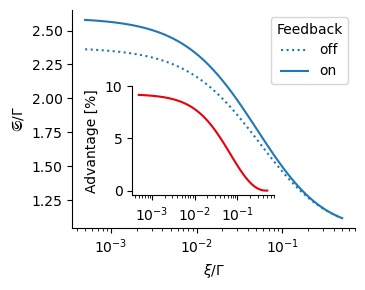

In [18]:
fig, (ax1) = plt.subplots()
fig.set_figheight(3)
fig.set_figwidth(15/4)
ax1.semilogx(Gammas_opt, opt_SNRs_no_feedback_under_dephasing,linestyle='dotted',label='off',color='tab:blue')
ax1.semilogx(Gammas_opt, opt_SNRs_with_feedback_under_dephasing,linestyle='solid', label='on',color='tab:blue')
ax1.set_xlabel(r'$\xi/\Gamma$')
ax1.set_ylabel(r'$\mathfrak{S}/\Gamma$')
ax1.legend(title='Feedback')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


inset_ax = ax1.inset_axes([0.2125,0.15,0.5,0.5])
inset_ax.semilogx(Gammas_opt, 100*opt_SNRs_with_feedback_under_dephasing/opt_SNRs_no_feedback_under_dephasing-100,color=color_list[3])
inset_ax.set_ylabel('Advantage [%]')
inset_ax.set_yticks([0,5,10])
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)
inset_ax.set_facecolor('none')
fig.tight_layout()
plt.savefig('robustness_against_dephasing_with_opt_parameters.png',dpi=600)

# Beyond two-dimensional memory spaces

In [56]:
def Projm(m,M):
    proj = np.zeros((M))
    proj[m] = 1
    proj = np.diag(proj)
    return proj

def Jumpm(m_final,m_initial,M):
    jump_op = np.zeros((M,M))
    jump_op[m_final,m_initial] = 1
    return jump_op

def H1m(E,m,M):
    H = np.diag([-1/2, 1/2])
    return np.kron(H*E,np.kron(Id(2),Projm(m,M)))

def H2m(E,m,M):
    H = np.diag([-1/2, 1/2])
    return np.kron(Id(2),np.kron(H*E,Projm(m,M)))

def J1m(phi,m_final,m_initial,M):
    return np.kron(J_phi(phi), np.kron(Id(2), Jumpm(m_final,m_initial,M)))

def J2m(phi,m_final,m_initial,M):
    return np.kron(Id(2), np.kron(J_phi(phi), Jumpm(m_final,m_initial,M)))

In [57]:
def SNR_under_2qubitfeedback_arbitrary_memory(Es,m_update,M,phi):

    H = np.zeros((2*2*M,2*2*M))
    Js = []
    current_op_list = []
    weights = []    
    
    for m in range(0,M):
        H = H + H1m(Es[m][0],m,M) + H2m(Es[m][1],m,M)
        J1 = J1m(phi,m_update[m][0],m,M)
        J2 = J2m(phi,m_update[m][1],m,M)
        Js.extend([J1,J2])
        current_op_list.extend([calc_jump_channel(J1),calc_jump_channel(J2)])
        weights.extend([1,1])
    
    Liouville = calc_Liouville(H, Js)
    _,_, SNR = evaluate_SNR(Liouville,current_op_list,weights)

    return SNR

In [ ]:
opt_pars_tick_difference = {}
opt_pars_full_sequence = {}

Note, the following two cells each take roughly 90 minutes to execute.

In [34]:
for M in range(2,9):

    opt_pars_tick_difference[M] = {}

    m_update = []
    initial_pars = []

    for m in range(0,M):
        m_update.append([max(0,m-1),min(m+1,M-1)])
        initial_pars.append(1)
    
    opt_pars_tick_difference[M]['m_update'] = m_update

    def neg_SNR_under_2qubitfeedback_tick_difference_memory(x):
        Es = [x[0:M],list(reversed(x[0:M]))]
        Es = [list(row) for row in zip(*Es)]
        return -SNR_under_2qubitfeedback_arbitrary_memory(Es,m_update,M,x[M])

    initial_pars.append(0.9)
    
    min_pars_tick_difference = fmin(neg_SNR_under_2qubitfeedback_tick_difference_memory, initial_pars)
    Es = [min_pars_tick_difference[0:M],reversed(min_pars_tick_difference[0:M])]
    Es = [list(row) for row in zip(*Es)]

    opt_pars_tick_difference[M]['Es'] = Es
    opt_pars_tick_difference[M]['phi'] = min_pars_tick_difference[M]

with open('opt_pars_tick_difference.pickle', 'wb') as handle:
    pickle.dump(opt_pars_tick_difference, handle, protocol=pickle.HIGHEST_PROTOCOL)

Optimization terminated successfully.
         Current function value: -2.594612
         Iterations: 52
         Function evaluations: 97
Optimization terminated successfully.
         Current function value: -2.540103
         Iterations: 71
         Function evaluations: 125
Optimization terminated successfully.
         Current function value: -2.484622
         Iterations: 130
         Function evaluations: 221
Optimization terminated successfully.
         Current function value: -2.457181
         Iterations: 225
         Function evaluations: 366
Optimization terminated successfully.
         Current function value: -2.441123
         Iterations: 252
         Function evaluations: 393
Optimization terminated successfully.
         Current function value: -2.430661
         Iterations: 449
         Function evaluations: 671
Optimization terminated successfully.
         Current function value: -2.423401
         Iterations: 487
         Function evaluations: 716


In [34]:
for M in range(1,4,1):

    opt_pars_full_sequence[2**M] = {}

    m_update = []
    initial_pars = [opt_pars_qubit_clockwork['E']]

    for _ in range(0,3):
        initial_pars = 2*initial_pars
        for idx,_ in enumerate(initial_pars):
            if idx<len(initial_pars)/2:
                initial_pars[idx] = initial_pars[idx]*opt_pars_Pi_switch['alpha_1']
            else:
                initial_pars[idx] = initial_pars[idx]*opt_pars_Pi_switch['alpha_2']

    for m in range(0,2**M):
        m_array = np.array([int(i) for i in bin(m)[2:].zfill(M)])
        m_array_0 = np.concatenate((m_array[1:M],np.array([0])))
        m_array_1 = np.concatenate((m_array[1:M],np.array([1])))
        m_0 = sum(bit * (2 ** i) for i, bit in enumerate(m_array_0[::-1]))
        m_1 = sum(bit * (2 ** i) for i, bit in enumerate(m_array_1[::-1]))
        m_update.append([m_0, m_1])
    
    opt_pars_full_sequence[2**M]['m_update'] = m_update

    def neg_SNR_under_2qubitfeedback_full_sequence_memory(x):
        Es = []
        for _ in range(0,2**M):
            Es.append([None,None])
        for m in range(0,2**M):
            Es[m][0]=x[m]
            Es[m^(2**M-1)][1]=x[m]
        return -SNR_under_2qubitfeedback_arbitrary_memory(Es,m_update,2**M,x[2**M])

    initial_pars.append(1.15)
    
    min_pars_full_sequence = fmin(neg_SNR_under_2qubitfeedback_full_sequence_memory,initial_pars)
    Es = []
    for _ in range(0,2**M):
        Es.append([None,None])
    for m in range(0,2**M):
        Es[m][0]=min_pars_full_sequence[m]
        Es[m^(2**M-1)][1]=min_pars_full_sequence[m]

    opt_pars_full_sequence[2**M]['Es'] = Es
    opt_pars_full_sequence[2**M]['phi'] = min_pars_full_sequence[2**M]

with open('opt_pars_full_sequence.pickle', 'wb') as handle:
    pickle.dump(opt_pars_full_sequence, handle, protocol=pickle.HIGHEST_PROTOCOL)

Optimization terminated successfully.
         Current function value: -2.594612
         Iterations: 169
         Function evaluations: 288
Optimization terminated successfully.
         Current function value: -2.650514
         Iterations: 265
         Function evaluations: 422
Optimization terminated successfully.
         Current function value: -2.668919
         Iterations: 569
         Function evaluations: 823


In [58]:
with open('opt_pars_tick_difference.pickle', 'rb') as handle:
    opt_pars_tick_difference_loaded = pickle.load(handle)
with open('opt_pars_full_sequence.pickle', 'rb') as handle:
    opt_pars_full_sequence_loaded = pickle.load(handle)
with open('opt_pars_qubit_clockwork.pickle', 'rb') as handle:
    opt_pars_qubit_clockwork_loaded = pickle.load(handle)

Ms_tick_difference = list(opt_pars_tick_difference_loaded.keys())
SNRs_tick_difference = []
Ms_full_sequence = list(opt_pars_full_sequence_loaded.keys())
SNRs_full_sequence = []

for M in Ms_tick_difference:
    SNRs_tick_difference.append(SNR_under_2qubitfeedback_arbitrary_memory(opt_pars_tick_difference_loaded[M]['Es'],
                                                                        opt_pars_tick_difference_loaded[M]['m_update'],
                                                                        M,
                                                                        opt_pars_tick_difference_loaded[M]['phi']))

for M in Ms_full_sequence:
    SNRs_full_sequence.append(SNR_under_2qubitfeedback_arbitrary_memory(opt_pars_full_sequence_loaded[M]['Es'],
                                                                        opt_pars_full_sequence_loaded[M]['m_update'],
                                                                        M,
                                                                        opt_pars_full_sequence_loaded[M]['phi']))

baseline = 2*qubit_clock_SNR([opt_pars_qubit_clockwork_loaded['E'], opt_pars_qubit_clockwork_loaded['phi']])

def SNR2adv(S):
    return 100*S/baseline - 100

def adv2SNR(x):
    return ((x+100)/100)*baseline

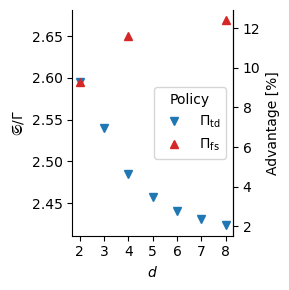

In [59]:
fig, (ax1) = plt.subplots()
fig.set_figheight(3)
fig.set_figwidth(3)
ax1.plot(Ms_tick_difference, SNRs_tick_difference,marker='v',linestyle='',label=r'$\Pi_{\mathrm{td}}$',color='tab:blue')
ax1.plot(Ms_full_sequence, SNRs_full_sequence, marker='^',linestyle='',label=r'$\Pi_{\mathrm{fs}}$',color='tab:red')

ax1.set_xlabel(r'$d$')
ax1.set_ylabel(r'$\mathfrak{S}/\Gamma$')
ax1.legend(title='Policy')
ax1.spines['top'].set_visible(False)
ax1.set_xticks([2,3,4,5,6,7,8])

secax = ax1.secondary_yaxis('right', functions=(SNR2adv,adv2SNR))
secax.set_ylabel('Advantage [%]')
fig.tight_layout()
plt.savefig('higher_d_memory.png',dpi=600)

### Creating Tables I&II

In [60]:
with open('opt_pars_tick_difference.pickle', 'rb') as handle:
    opt_pars_tick_difference_loaded = pickle.load(handle)
with open('opt_pars_full_sequence.pickle', 'rb') as handle:
    opt_pars_full_sequence_loaded = pickle.load(handle)
with open('opt_pars_qubit_clockwork.pickle', 'rb') as handle:
    opt_pars_qubit_clockwork_loaded = pickle.load(handle)

In [61]:
print('Table I - Energies and Angle of \Pi_{\mathrm{fs}} renormalized by E* and \phi*\n')
m_encoded = 'd'
for m in range(0,8):
    m_encoded += ' & ' + str(np.array([int(i) for i in bin(m)[2:].zfill(3)])+1) 
print(m_encoded  + ' & \\phi \\\\')
for M in opt_pars_full_sequence_loaded.keys():
    renormalized_energies = '%d'%M
    renormalized_phi = str(np.round(opt_pars_full_sequence_loaded[M]['phi']/opt_pars_qubit_clockwork_loaded['phi'],decimals=3))

    for Energy in np.transpose(np.array(opt_pars_full_sequence_loaded[M]['Es']))[0]:
        renormalized_energies += ' & ' + str(np.round(Energy/opt_pars_qubit_clockwork_loaded['E'],decimals=3))
    print(renormalized_energies + (9-M)*' & ' + renormalized_phi + ' \\\\')
print('\nThe encoding: rightmost number indicates from which clockwork the last observed jump stemmed\n\n---------------------------------------------------------------------------------------------\n')

print('Table II - Energies and Angle of \Pi_{\mathrm{td}} renormalized by E* and \phi*\n')
m_encoded = 'd'
for m in range(0,8):
    m_encoded += ' & ' + str(m) 
print(m_encoded  + ' & \\phi \\\\')
for M in opt_pars_tick_difference_loaded.keys():
    renormalized_energies = '%d'%M
    renormalized_phi = str(np.round(opt_pars_tick_difference_loaded[M]['phi']/opt_pars_qubit_clockwork_loaded['phi'],decimals=3))

    for Energy in np.transpose(np.array(opt_pars_tick_difference_loaded[M]['Es']))[0]:
        renormalized_energies += ' & ' + str(np.round(Energy/opt_pars_qubit_clockwork_loaded['E'],decimals=3))
    print(renormalized_energies + (9-M)*' & ' + renormalized_phi + ' \\\\')

Table I - Energies and Angle of \Pi_{\mathrm{fs}} renormalized by E* and \phi*

d & [1 1 1] & [1 1 2] & [1 2 1] & [1 2 2] & [2 1 1] & [2 1 2] & [2 2 1] & [2 2 2] & \phi \\
2 & 1.2 & 0.883 &  &  &  &  &  &  & 1.008 \\
4 & 1.317 & 0.933 & 1.152 & 0.782 &  &  &  &  & 1.009 \\
8 & 1.514 & 0.992 & 1.168 & 0.765 & 1.239 & 0.944 & 1.15 & 0.908 & 1.007 \\

The encoding: rightmost number indicates from which clockwork the last observed jump stemmed

---------------------------------------------------------------------------------------------

Table II - Energies and Angle of \Pi_{\mathrm{td}} renormalized by E* and \phi*

d & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & \phi \\
2 & 1.2 & 0.883 &  &  &  &  &  &  & 1.008 \\
3 & 1.213 & 1.019 & 0.861 &  &  &  &  &  & 1.005 \\
4 & 1.205 & 1.023 & 1.003 & 0.857 &  &  &  &  & 1.003 \\
5 & 1.194 & 1.026 & 1.013 & 0.997 & 0.854 &  &  &  & 1.003 \\
6 & 1.189 & 1.024 & 1.021 & 1.008 & 0.991 & 0.85 &  &  & 1.002 \\
7 & 1.185 & 1.025 & 1.021 & 1.018 & 1.001 & 0.987 & 0